# Monte Carlo Option Pricing — Simulation & Convergence Analysis

This project prices European options using Monte Carlo simulation, compares results
to Black–Scholes closed-form prices, and analyzes convergence as the number
of simulated paths increases.

Monte Carlo pricing appears in:
- derivatives pricing
- risk management (VaR / exposure simulation)
- exotic option pricing
- quant research

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

np.random.seed(42)

In [2]:
def norm_cdf(x):
    return 0.5 * (1 + erf(x / np.sqrt(2)))

def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm_cdf(d1) - K*np.exp(-r*T)*norm_cdf(d2)

In [3]:
def mc_price_call(S0, K, r, sigma, T, N_paths=10_000, N_steps=252):
    dt = T / N_steps

    # simulate price paths
    Z = np.random.normal(0, 1, size=(N_paths, N_steps))
    price_paths = S0 * np.exp(np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z, axis=1))

    # terminal payoff
    ST = price_paths[:, -1]
    payoff = np.maximum(ST - K, 0)

    # discount back
    return np.exp(-r*T) * payoff.mean()

In [4]:
S0 = 100
K  = 100
r  = 0.02
sigma = 0.20
T  = 1.0

In [5]:
mc = mc_price_call(S0, K, r, sigma, T, N_paths=20_000)
bs = bs_call(S0, K, r, sigma, T)

mc, bs, mc - bs

(np.float64(8.743326278215237),
 np.float64(8.916037278572539),
 np.float64(-0.17271100035730136))

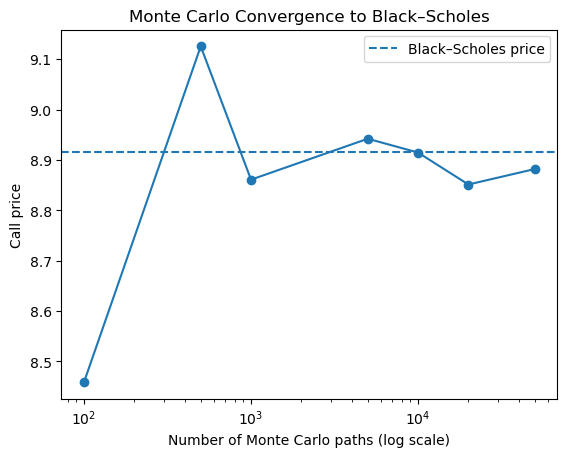

In [6]:
path_sizes = [100, 500, 1000, 5000, 10_000, 20_000, 50_000]
estimates = []

for N in path_sizes:
    est = mc_price_call(S0, K, r, sigma, T, N_paths=N)
    estimates.append(est)

plt.plot(path_sizes, estimates, marker='o')
plt.axhline(bs, linestyle='--', label="Black–Scholes price")
plt.xscale('log')
plt.xlabel("Number of Monte Carlo paths (log scale)")
plt.ylabel("Call price")
plt.title("Monte Carlo Convergence to Black–Scholes")
plt.legend()
plt.show()

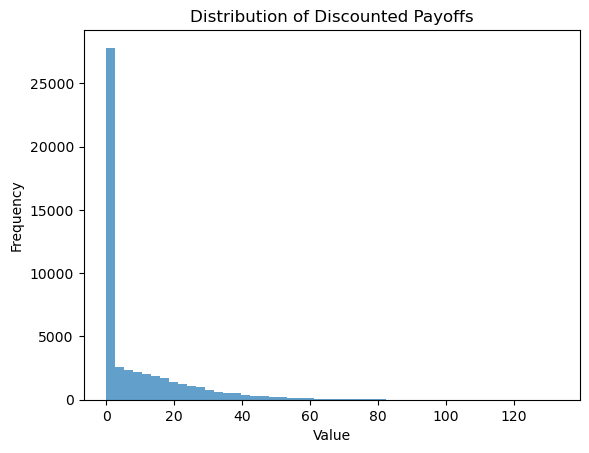

In [9]:
paths = 50_000
dt = T / 252
Z = np.random.normal(0, 1, size=(paths, 252))
paths_sim = S0 * np.exp(np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z, axis=1))

ST = paths_sim[:, -1]
payoff = np.maximum(ST - K, 0)
disc_payoff = np.exp(-r*T) * payoff

plt.hist(disc_payoff, bins=50, alpha=0.7)
plt.title("Distribution of Discounted Payoffs")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# Final Insights

### 1. Monte Carlo converges slowly but reliably
As the number of Monte Carlo paths increases, the price converges toward the
Black–Scholes value. The convergence rate is about \(1/\sqrt{N}\), explaining
why variance reduction methods are important in practice.

### 2. Distribution of outcomes is asymmetric
Payoffs are right-skewed: most paths finish slightly above or below the strike,
while a few paths generate large gains.

### 3. Monte Carlo is essential for exotic pricing
While Black–Scholes works for European options, Monte Carlo handles:
- Asian options  
- Barrier options  
- Path-dependent exotics  

### 4. Real-world use cases
Banks and hedge funds rely on Monte Carlo for:
- risk simulations (VaR)  
- pricing structured products  
- exposure calculation (CVA)  
- scenario stress testing  


##  Pricing an Asian Option with Monte Carlo

So far we priced **European options**, where the payoff depends only on the **final price** \( S_T \).

Now we price an **Asian call option**, where the payoff depends on the **average price over the life of the option**

Asian options are **path-dependent**, so there is *no simple closed-form Black–Scholes formula* in general.  
Monte Carlo is the natural method here.

In [10]:
def simulate_gbm_paths(S0, r, sigma, T, N_paths=10_000, N_steps=252):
    """
    Simulate Geometric Brownian Motion (GBM) paths for the underlying.
    Returns array of shape (N_paths, N_steps).
    """
    dt = T / N_steps
    Z = np.random.normal(0, 1, size=(N_paths, N_steps))
    
    # log S_t increments
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    
    paths = S0 * np.exp(log_paths)
    return paths

In [11]:
def mc_price_asian_call(S0, K, r, sigma, T, 
                        N_paths=10_000, N_steps=252):
    """
    Price an arithmetic-average Asian call option using Monte Carlo.
    Payoff = max(avg(S_t) - K, 0).
    """
    paths = simulate_gbm_paths(S0, r, sigma, T, N_paths, N_steps)
    
    # Arithmetic average of the price along each path
    S_avg = paths.mean(axis=1)
    
    # Asian call payoff
    payoff = np.maximum(S_avg - K, 0)
    
    # Discounted expectation
    price = np.exp(-r * T) * payoff.mean()
    return price

###  Comparing European vs Asian Call Prices

For the same parameters \((S_0, K, r, \sigma, T)\), we now compare:

- **European call price** (depends only on \( S_T \))
- **Asian call price** (depends on the average \( \bar{S} \))

Asian options typically have **lower prices** than European options  
with the same strike, because averaging reduces the effect of extreme high prices.

In [12]:
# Monte Carlo European call (using existing mc_price_call or new version with simulate_gbm_paths)
def mc_price_european_call_from_paths(S0, K, r, sigma, T, 
                                      N_paths=10_000, N_steps=252):
    paths = simulate_gbm_paths(S0, r, sigma, T, N_paths, N_steps)
    ST = paths[:, -1]
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * payoff.mean()

mc_euro = mc_price_european_call_from_paths(S0, K, r, sigma, T, N_paths=20_000)
mc_asian = mc_price_asian_call(S0, K, r, sigma, T, N_paths=20_000)

print(f"Monte Carlo European call: {mc_euro:.4f}")
print(f"Monte Carlo Asian call   : {mc_asian:.4f}")
print(f"Difference (Asian - Euro): {mc_asian - mc_euro:.4f}")

Monte Carlo European call: 8.7153
Monte Carlo Asian call   : 5.0156
Difference (Asian - Euro): -3.6998


### Volatility effect: Asian vs European

Because Asian options average the price over time, they are **less sensitive to volatility** than European options.

To see this, we compare prices across different vol levels for both products.

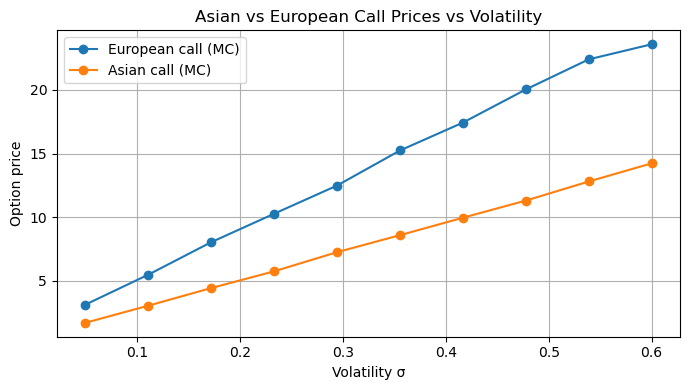

In [13]:
sigma_values = np.linspace(0.05, 0.60, 10)

euro_prices = []
asian_prices = []

for sig in sigma_values:
    euro_prices.append(
        mc_price_european_call_from_paths(S0, K, r, sig, T, N_paths=15_000)
    )
    asian_prices.append(
        mc_price_asian_call(S0, K, r, sig, T, N_paths=15_000)
    )

plt.figure(figsize=(7,4))
plt.plot(sigma_values, euro_prices, marker="o", label="European call (MC)")
plt.plot(sigma_values, asian_prices, marker="o", label="Asian call (MC)")
plt.xlabel("Volatility σ")
plt.ylabel("Option price")
plt.title("Asian vs European Call Prices vs Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

From the volatility sweep:

- Both **European** and **Asian** call prices increase with volatility.
- For the same parameters, the **Asian call is consistently cheaper**:
  - averaging smooths out extreme price moves
  - reduces upside from rare very-high terminal prices

**Business takeaway:**

- Asian options are often used when the buyer wants exposure to the *average* price (e.g. commodities, FX baskets) and is willing to pay less than for a plain European call.
- From a modeling perspective, Monte Carlo is the natural tool for pricing such path-dependent payoffs.


## Down-and-Out Barrier Call Option (Monte Carlo)

So far we priced:

- European calls (payoff depends only on \( S_T \))
- Asian calls (payoff depends on the average price path)

Now we price a **down-and-out barrier call** — a path-dependent exotic option.

### Payoff definition (down-and-out call)

- There is a barrier level \( B < S_0 \).
- If the underlying **ever touches or falls below** \( B \) during the life of the option,  
  the option is **knocked out** → payoff = 0.
- Otherwise, if the barrier is never hit and the option expires in the money

In [14]:
def mc_price_down_and_out_call(S0, K, B, r, sigma, T, 
                               N_paths=10_000, N_steps=252):
    """
    Monte Carlo pricing of a down-and-out call option.

    Barrier B is below S0. If at any time S_t <= B, the option is knocked out (payoff = 0).
    Otherwise, payoff = max(S_T - K, 0).
    """
    paths = simulate_gbm_paths(S0, r, sigma, T, N_paths, N_steps)  # shape: (N_paths, N_steps)

    # Check barrier condition along each path
    # knocked_out[i] = True if the i-th path crosses the barrier
    knocked_out = (paths <= B).any(axis=1)

    ST = paths[:, -1]
    vanilla_payoff = np.maximum(ST - K, 0)

    # Apply barrier condition: payoff = 0 if knocked_out
    payoff = np.where(knocked_out, 0.0, vanilla_payoff)

    price = np.exp(-r * T) * payoff.mean()
    return price

In [15]:
def mc_price_down_and_out_call(S0, K, B, r, sigma, T, 
                               N_paths=10_000, N_steps=252):
    """
    Monte Carlo pricing of a down-and-out call option.

    Barrier B is below S0. If at any time S_t <= B, the option is knocked out (payoff = 0).
    Otherwise, payoff = max(S_T - K, 0).
    """
    paths = simulate_gbm_paths(S0, r, sigma, T, N_paths, N_steps)  # shape: (N_paths, N_steps)

    # Check barrier condition along each path
    # knocked_out[i] = True if the i-th path crosses the barrier
    knocked_out = (paths <= B).any(axis=1)

    ST = paths[:, -1]
    vanilla_payoff = np.maximum(ST - K, 0)

    # Apply barrier condition: payoff = 0 if knocked_out
    payoff = np.where(knocked_out, 0.0, vanilla_payoff)

    price = np.exp(-r * T) * payoff.mean()
    return price

### Vanilla vs Down-and-Out Call Price

We compare:

- A standard **European call** (no barrier)
- A **down-and-out call** with barrier \( B < S_0 \)

We expect the barrier call to be **cheaper**, because it can knock out and become worthless if the underlying falls too much at any time.

In [16]:
B = 80  # barrier below S0 = 100

mc_vanilla = mc_price_european_call_from_paths(S0, K, r, sigma, T, N_paths=30_000)
mc_barrier = mc_price_down_and_out_call(S0, K, B, r, sigma, T, N_paths=30_000)

print(f"Monte Carlo European call (no barrier): {mc_vanilla:.4f}")
print(f"Down-and-out call (barrier B={B}):      {mc_barrier:.4f}")
print(f"Price difference (barrier - vanilla):   {mc_barrier - mc_vanilla:.4f}")

Monte Carlo European call (no barrier): 8.9252
Down-and-out call (barrier B=80):      8.8446
Price difference (barrier - vanilla):   -0.0805


### Effect of Barrier Level on Option Price

Intuition:

- If the barrier is **very low** (e.g. B close to 0), it almost never gets hit →  
  the barrier option behaves like a vanilla call.
- If the barrier is **close to S₀ or K**, it is likely to be hit →  
  the option is frequently knocked out, so the price drops.

We now sweep the barrier level and observe how the barrier call price changes.

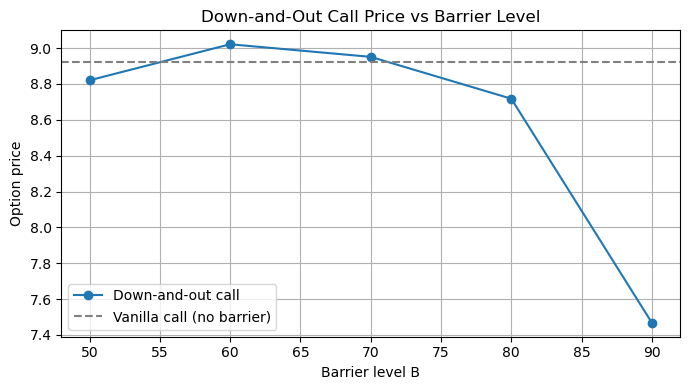

In [17]:
barrier_levels = [50, 60, 70, 80, 90]  # all below S0 = 100
prices_barrier = []

for B_level in barrier_levels:
    price_B = mc_price_down_and_out_call(S0, K, B_level, r, sigma, T, 
                                         N_paths=20_000, N_steps=252)
    prices_barrier.append(price_B)

plt.figure(figsize=(7,4))
plt.plot(barrier_levels, prices_barrier, marker="o", label="Down-and-out call")
plt.axhline(mc_vanilla, linestyle="--", color="gray", label="Vanilla call (no barrier)")
plt.xlabel("Barrier level B")
plt.ylabel("Option price")
plt.title("Down-and-Out Call Price vs Barrier Level")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Volatility Effect on Barrier Options

Volatility has two opposing effects:

- For vanilla calls: higher volatility → higher option price (more upside potential).
- For down-and-out calls: higher volatility also means **higher probability of hitting the barrier**, which *reduces* value.

We examine how the barrier call price reacts to changes in σ.

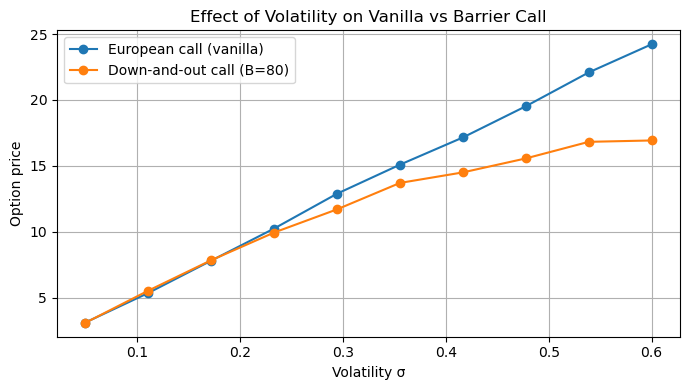

In [18]:
sigma_values = np.linspace(0.05, 0.60, 10)

prices_vanilla_vol = []
prices_barrier_vol = []

B_fixed = 80  # fixed barrier for this experiment

for sig in sigma_values:
    pv = mc_price_european_call_from_paths(S0, K, r, sig, T, N_paths=15_000)
    pb = mc_price_down_and_out_call(S0, K, B_fixed, r, sig, T, N_paths=15_000)
    prices_vanilla_vol.append(pv)
    prices_barrier_vol.append(pb)

plt.figure(figsize=(7,4))
plt.plot(sigma_values, prices_vanilla_vol, marker="o", label="European call (vanilla)")
plt.plot(sigma_values, prices_barrier_vol, marker="o", label=f"Down-and-out call (B={B_fixed})")
plt.xlabel("Volatility σ")
plt.ylabel("Option price")
plt.title("Effect of Volatility on Vanilla vs Barrier Call")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation & Risk Insight

From the barrier option analysis:

1. **Price vs barrier level**
   - As the barrier **moves up** (closer to S₀), the option is more likely to knock out.
   - This **reduces the expected payoff**, so the barrier option price **falls**.
   - For very low barriers, the price approaches the vanilla call.

2. **Volatility effect**
   - For vanilla calls, higher σ always increases value (more chance of large upside).
   - For down-and-out calls, higher σ has a mixed effect:
     - More upside **if the barrier is not hit**.
     - But also **more probability of hitting the barrier** and losing everything.
   - The net impact depends on the barrier location and parameter set.

3. **Business interpretation**
   - Barrier options are cheaper hedging instruments because they contain a built-in
     “cancellation condition” (knock-out).
   - Traders and risk managers must monitor **path risk** not just endpoint risk.
   - This type of modeling is common in:
     - Equity structured products
     - FX exotics
     - Volatility and correlation desks
